# ABCMB Basics

In [1]:
import sys
sys.path.append('..')
from jax import jit, jacfwd
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import time

from abcmb.main import Model

## Setting up a `Model`

ABCMB is object-oriented, with all calculations running through an instance of `abcmb.main.Model`. The default ABCMB model is $\Lambda$CDM cosmology in flat space and without neutrino masses. The five fluids present are cold dark matter, baryons, photons, massless neutrinos, and the cosmological constant. 

To start, we initialize an instance of `Model` with all default options.  Once initialized, our instance of `Model` can be used for calculations, either with `run_cosmology` or just by calling the initialized model.

In [8]:
model = Model()
output, aux = model.run_cosmology()
# equivalent: output, aux = model()

You did not specify either N_nu_massless or Neff, and did not ask LINX to compute these quantities.
N_nu_massless will be set to 3-N_nu_massive=3.

              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      



`Model.run_cosmology` returns two quantities: `output` and `aux`. Of these, the CMB power spectra, as well as the matter power spectrum if it was requested, are stored in the tuple `output`. `aux` on the other hand contains the $\ell$ axis matching the CMB spectra or the $k$ axis for the $P(k)$. If you request either background or perturbations to be returned (illustrated below), they are included in `aux` as well.

We can plot the results. Note by default ABCMB outputs the true $C_{\ell}$'s and not the conventionally defined $D_{\ell} \equiv \frac{\ell(\ell+1)}{2\pi}C_{\ell}$. We should make sure to include this before plotting:

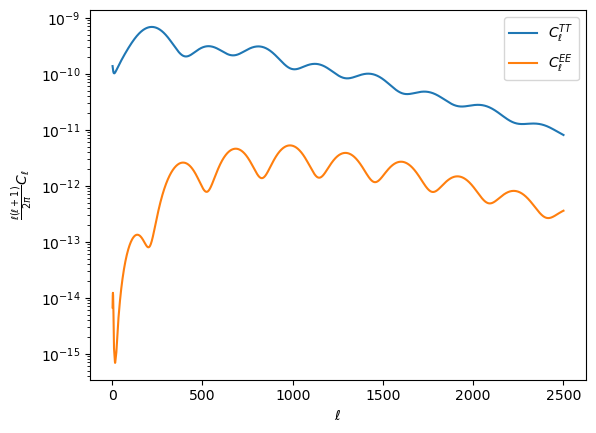

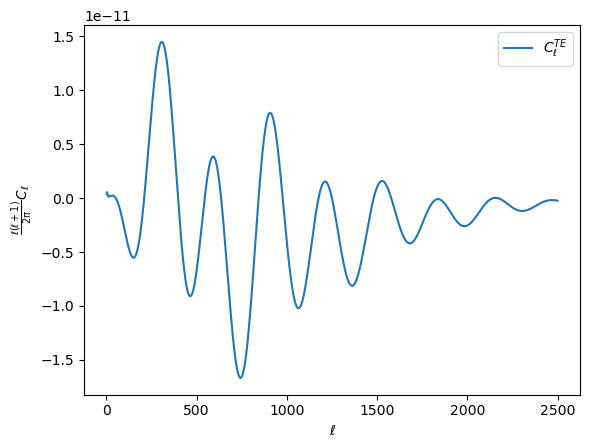

In [9]:
ABC_ell = aux[0]
ABC_tt = output[0] * ABC_ell * (ABC_ell+1)/(2 * jnp.pi)
ABC_te = output[1] * ABC_ell * (ABC_ell+1)/(2 * jnp.pi)
ABC_ee = output[2] * ABC_ell * (ABC_ell+1)/(2 * jnp.pi)

plt.plot(ABC_ell, ABC_tt,label=r'$C_{\ell}^{TT}$')
plt.plot(ABC_ell, ABC_ee,label=r'$C_{\ell}^{EE}$')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\frac{\ell(\ell + 1)}{2\pi} C_{\ell}$')
plt.yscale("log")
plt.legend()
plt.show()

plt.plot(ABC_ell, ABC_te,label=r'$C_{\ell}^{TE}$')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\frac{\ell(\ell + 1)}{2\pi} C_{\ell}$')
#plt.yscale("log")
plt.legend()
plt.show()

There are a number of run options that can be specified at initialization. We note that these are $\textit{not}$ cosmological parameters, but setup parameters related to accuracy, tolerances, input/output etc. All such parameters should be passed in via the `specs` dictionary. For now, let's specify `lmin` and `lmax` (the boundary `l` at which to output power spectra), and also compute the lensed CMB spectrum with `lensing` turned on.

In [2]:
# output_Cl = True to return TT, TE, EE spectra.
# output_Pk = False to turn off P(k) computation for now.
# l_min and l_max define range of output modes ell for computation (inclusive)
# lensing = True includes lensing (False by default)
model = Model(output_Cl=True,output_Pk=False,l_min=2,l_max=2100, lensing=True)

In [ ]:
# equivalent way to specify specs:

# specs = {
#     "output_Cl" : True,  # Will return TT, TE, EE spectra.
#     "output_Pk" : False, # Turn off P(k) computation for now.
#     "l_min" : 2,
#     "l_max" : 2100,      # Will output at all integer l's between l_min and l_max (both inclusive).
#     "lensing" : True     # Include lensing. This is False by default, so be sure to turn it on.
# }

# model = Model(**specs)

`Model.run_cosmology` sets up background quantities (like $x_e$ and $H$), uses those background quantities to compute the evolution of perturbations, and then finally integrates the resulting transfer function to get $C_{\ell}$s. 

In [4]:
output, aux = model.run_cosmology()


              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      



The first time you run a new model will take some time due to JAX's JIT compilation. However, any subsequent run on the _same_ `Model` using _different_ params (**not** different specs) will be much faster, since JAX automatically calls the cached compiled code.

We can plot our new result:

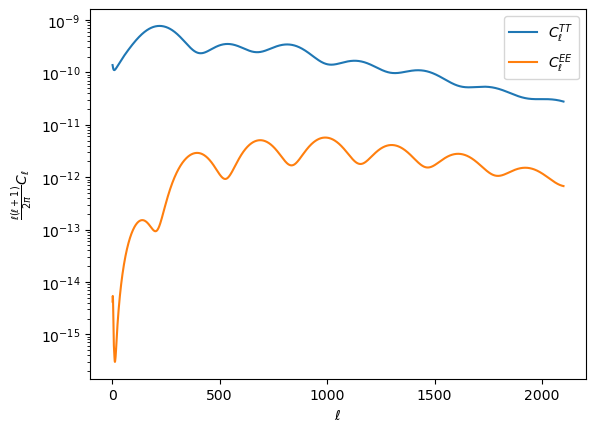

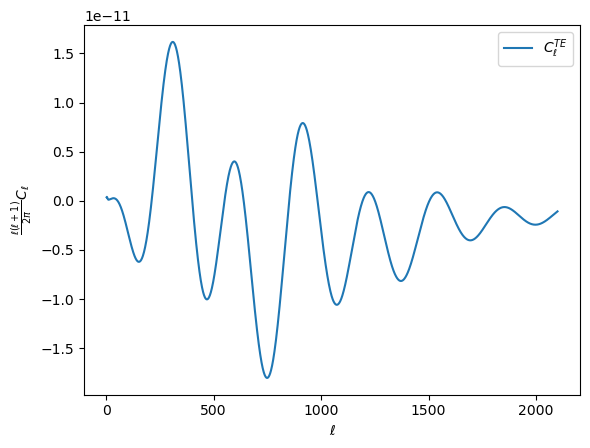

In [5]:
ABC_ell = aux[0]
ABC_tt = output[0] * ABC_ell * (ABC_ell+1)/(2 * jnp.pi)
ABC_te = output[1] * ABC_ell * (ABC_ell+1)/(2 * jnp.pi)
ABC_ee = output[2] * ABC_ell * (ABC_ell+1)/(2 * jnp.pi)

plt.plot(ABC_ell, ABC_tt,label=r'$C_{\ell}^{TT}$')
plt.plot(ABC_ell, ABC_ee,label=r'$C_{\ell}^{EE}$')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\frac{\ell(\ell + 1)}{2\pi} C_{\ell}$')
plt.yscale("log")
plt.legend()
plt.show()

plt.plot(ABC_ell, ABC_te,label=r'$C_{\ell}^{TE}$')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\frac{\ell(\ell + 1)}{2\pi} C_{\ell}$')
#plt.yscale("log")
plt.legend()
plt.show()

## Specifying params and run options

`Model` has a number of options that can be specified at initialization.  Attempting to change these options will trigger recompilation when `run_cosmology` is called.  See companion paper for a full list of options.

For example, let's change the `bbn_type` to `Table` to infer `params['YHe']` from `params['omega_b']` and `params['Neff']`. Let us also ask for $P(k)$ to be output by switching `output_Pk` to `True`, while leaving the CMB spectra out (note this will change the indexing in `output` and `aux`!). Both of these can again be specified in the `specs` dictionary:

In [3]:
specs["output_Cl"] = False
specs["output_Pk"] = True
specs["bbn_type"]  = "Table"
model2 = Model(specs)

The parameters dictionary can be changed without triggering recompilation, as long as all inputs to the same variable have the same `dtype` and `shape`.  It is recommended that inputs be wrapped in `jnp.array` to avoid recompilation. 

In the function below, we will be running `model2` for a few values of $\omega_b = \Omega_b h^2$, while keeping $\omega_m$ fixed by making up the missing portion with dark matter. Let's take a look at the results and the run time:

In [4]:
def f(omega_b):
    omega_m   = 0.3 * 0.7**2 
    omega_cdm = omega_m - omega_b
    params = {"omega_b" : omega_b, "omega_cdm" : omega_cdm}
    return model2.run_cosmology(params)

In [5]:
jf = jit(f) # run with the JIT-compiled version of the function

for omega_b in [jnp.array(0.015), jnp.array(0.02), jnp.array(0.025)]:
    s = time.time()
    # output contains p(k), aux c
    output, aux = jf(omega_b)
    output[0].block_until_ready() # Avoiding Jax asynchronous dispatch for faithful speedtest.
    print(time.time() - s)

    k  = aux[0]
    Pk = output[0]
    plt.loglog(k,Pk, label=r"$\omega_b={}$".format(omega_b))
plt.xlabel(r'$k [{\rm Mpc}^{-1}]$')
plt.ylabel(r'$P(k) [{\rm Mpc}^3]$')
plt.legend()
plt.show()

NameError: name 'f' is not defined

## Background and Perturbations

ABCMB runs and stores background and perturbation related quantities before using them to compute the output spectra. Of these, the background module contains various energy densities, Hubble, conformal time, as well as all recombination quantities such as the electron fraction. Perturbations stores a table of metric and fluid perturbations over time and wavenumbers.

You can specify the fields `output_background` and `output_perturbations` in the `specs` dictionary to `True`. Two objects containing these information are returned in a call:

In [13]:
specs = {
    "output_Cl" : False,
    "output_Pk" : False,
    "output_background"    : True,
    "output_perturbations" : True
}

myModel = Model(specs)

In [14]:
output, aux = myModel.run_cosmology({})
full_params = aux[0] # Full list of parameters used
PT          = aux[1] # A pertubations table object
BG          = aux[2] # A background object

You did not specify either N_nu_massless or Neff, and did not ask LINX to compute these quantities.
N_nu_massless will be set to 3-N_nu_massive=3.

              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      



In addition to the objects `PT` and `BG`, a full dictionary of input + derived parameters is always returned in aux preceding the background and perturbations. This dictionary is helpful in evaluating some of the background functions in addition to giving a general overview.

Some background quantities can be plotted. Such as Hubble:

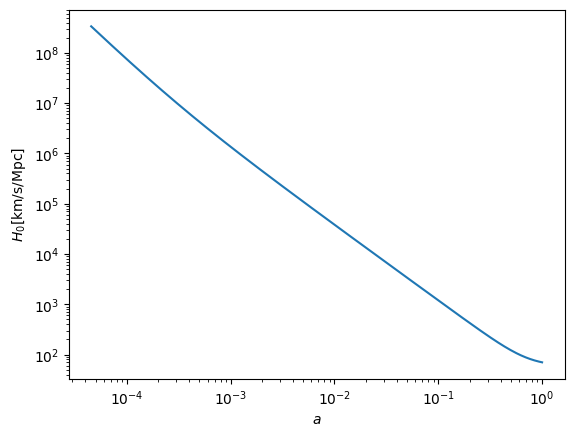

In [25]:
lna = jnp.linspace(-10, 0, 300)
hubble = BG.H(lna, full_params) / 3.24078e-20
plt.loglog(jnp.exp(lna), hubble)
plt.ylabel(r"$H_0 [{\rm km/s/Mpc}]$")
plt.xlabel(r"$a$")
plt.show()

The free electron fraction:

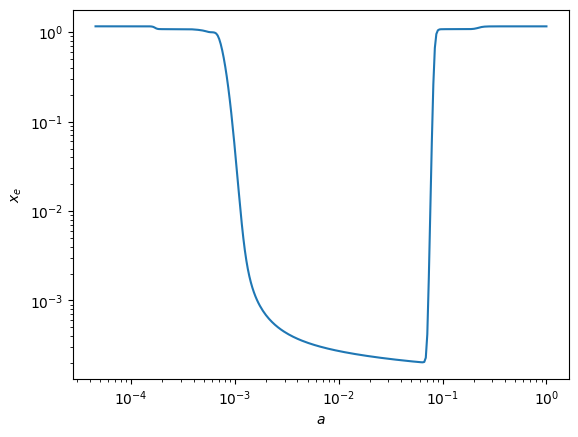

In [29]:
lna = jnp.linspace(-10, 0, 300)
xe = BG.xe(lna)
plt.loglog(jnp.exp(lna), xe)
plt.ylabel(r"$x_e$")
plt.xlabel(r"$a$")
plt.show()

Baryon temperature:

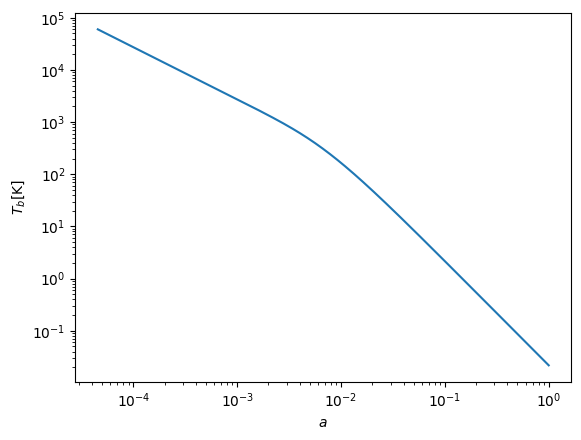

In [34]:
lna = jnp.linspace(-10, 0, 300)
Tm = BG.Tm(lna, full_params) / 8.617e-5 # Convert units to K
plt.loglog(jnp.exp(lna), Tm)
plt.ylabel(r"$T_b [\rm K]$")
plt.xlabel(r"$a$")
plt.show()

Perturbations of cosmological fluids are stored inside a `PerturbationsTable` (PT). The full list of stored quantities are as follows. All quantities are in the synchronous gauge, tabulated 2d arrays over the time axis `lna` and wavenumbers `k`. 

In [36]:
PT

PerturbationTable(
  k=f64[511],
  lna=f64[500],
  delta_m=f64[500,511],
  delta_dm=f64[500,511],
  delta_b=f64[500,511],
  theta_b=f64[500,511],
  theta_b_prime=f64[500,511],
  delta_g=f64[500,511],
  theta_g=f64[500,511],
  sigma_g=f64[500,511],
  Gg0=f64[500,511],
  Gg2=f64[500,511],
  metric_h=f64[500,511],
  metric_eta=f64[500,511],
  metric_h_prime=f64[500,511],
  metric_eta_prime=f64[500,511],
  metric_alpha=f64[500,511],
  metric_alpha_prime=f64[500,511]
)

These can also be plotted. For instance the photon temperature perturbations go as

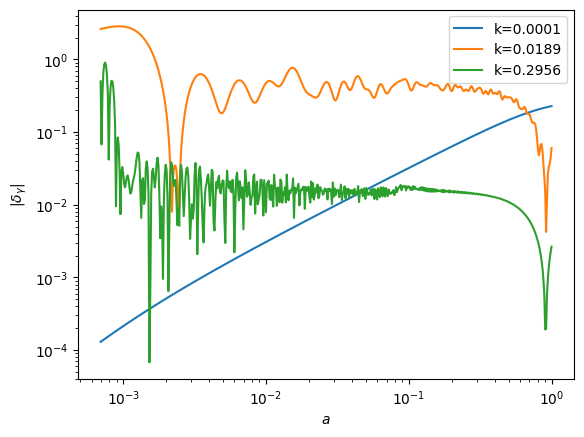

In [46]:
# plot the photon perturbation as a function of redshift for a couple different k's, in 1/Mpc
for k_ind in [10,250,500]:
    plt.loglog(jnp.exp(PT.lna), jnp.abs(PT.delta_g[:,k_ind]),label="k={k:.4f}".format(k=PT.k[k_ind]))
plt.legend()
plt.xlabel(r'$a$')
plt.ylabel(r'$|\delta_\gamma|$')
plt.show()

Baryon density and velocity perturbations for a couple of selected values of $k$:

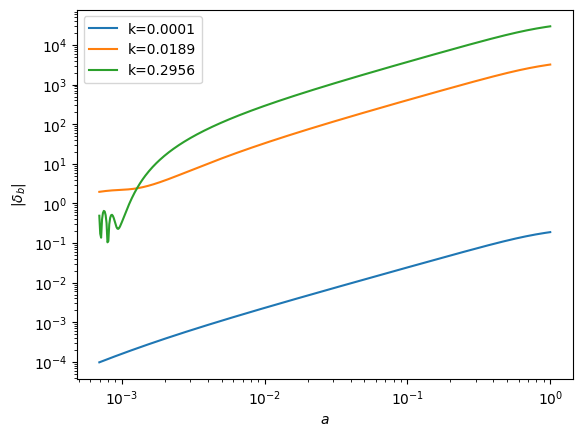

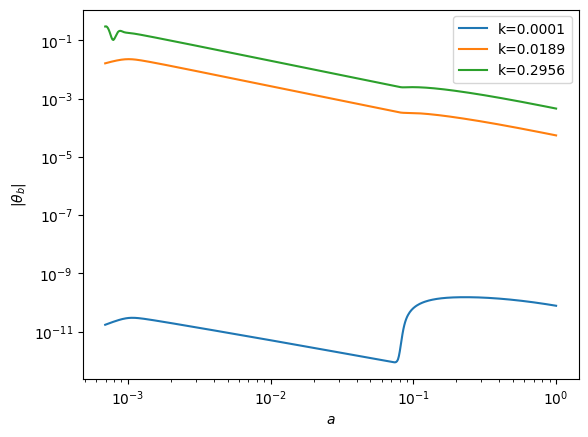

In [49]:
for k_ind in [10,250,500]:
    plt.loglog(jnp.exp(PT.lna), jnp.abs(PT.delta_b[:,k_ind]),label="k={k:.4f}".format(k=PT.k[k_ind]))
plt.legend()
plt.xlabel(r'$a$')
plt.ylabel(r'$|\delta_b|$')
plt.show()

for k_ind in [10,250,500]:
    plt.loglog(jnp.exp(PT.lna), jnp.abs(PT.theta_b[:,k_ind]),label="k={k:.4f}".format(k=PT.k[k_ind]))
plt.legend()
plt.xlabel(r'$a$')
plt.ylabel(r'$|\theta_b|$')
plt.show()